In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import matplotlib as mpl
mpl.style.use('default')

In [22]:
data = pd.read_csv("index_distance_2016_raw.csv")
data.head()

,x,y,no,group
0,27.211,1.311,0.0,y
1,27.211,1.427,0.0,ymax
2,27.211,1.194,0.0,ymin
3,47.838,1.498,1.0,y
4,47.838,1.479,1.0,ymax


In [23]:
data_1 = data[data['group'] == 'y']
data_1 = data_1.reset_index()[["x", "y"]]
ymin = data[data['group'] == 'ymin']["y"]
ymin = ymin.reset_index()
data_1["ymin"] = ymin["y"]
ymax = data[data['group'] == 'ymax']["y"]
ymax = ymax.reset_index()
data_1["ymax"] = ymax["y"]

tmp = data_1["ymin"]
data_1["ymin"] = np.min(np.array([data_1["ymin"], data_1["ymax"]]), axis=0)
data_1["ymax"] = np.max(np.array([data_1["ymax"], tmp]), axis=0)

In [24]:
data_1

,x,y,ymin,ymax
0,27.211,1.311,1.194,1.427
1,47.838,1.498,1.479,1.520
2,69.391,1.357,1.202,1.515
3,79.559,1.490,1.353,1.625
4,94.984,1.398,1.250,1.545
5,95.676,1.584,1.438,1.732
6,108.708,1.486,1.350,1.625
7,120.245,1.371,1.231,1.514
8,131.423,1.499,1.489,1.510
9,141.909,1.773,1.615,1.929


In [25]:
data_1.to_csv("index_distance_2016.csv", index=False)

Text(0, 0.5, 'spectral index')

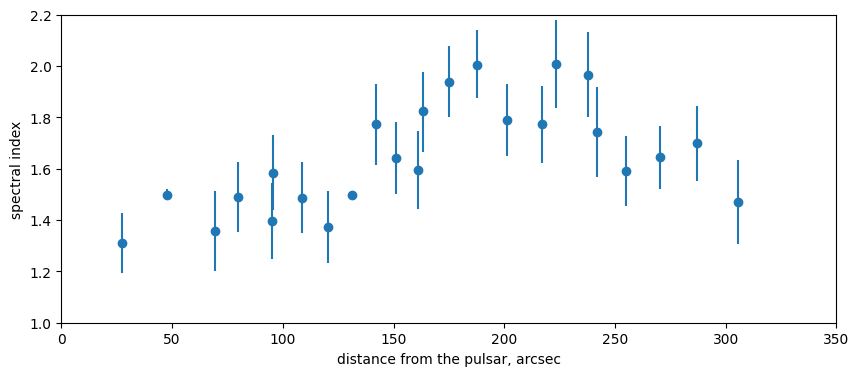

In [26]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.errorbar(data_1["x"], data_1["y"], yerr=[data_1["y"] - data_1["ymin"], data_1["ymax"] - data_1["y"]], fmt='o')

plt.xlim(0, 350)
plt.xlabel("distance from the pulsar, arcsec")

plt.ylim(1.0, 2.2)
plt.ylabel("spectral index")

In [27]:
data2 = pd.read_csv("index_flux_2016_raw.csv")
data2.head()

,x,y,no,group
0,2.621497,1.471545,0,y
1,2.621224,1.639818,0,ymax
2,2.621224,1.305727,0,ymin
3,2.911565,1.360136,1,y
4,2.911565,1.514773,1,ymax


In [28]:
data_2 = data2[data2['group'] == 'y']
data_2 = data_2.reset_index()[["x", "y"]]
ymin_2 = data2[data2['group'] == 'ymin']["y"]
ymin_2 = ymin_2.reset_index()
data_2["ymin"] = ymin_2["y"]
ymax_2 = data2[data2['group'] == 'ymax']["y"]
ymax_2 = ymax_2.reset_index()
data_2["ymax"] = ymax_2["y"]

tmp = data_2["ymin"]
data_2["ymin"] = np.min(np.array([data_2["ymin"], data_2["ymax"]]), axis=0)
data_2["ymax"] = np.max(np.array([data_2["ymax"], tmp]), axis=0)

In [29]:
data_2

,x,y,ymin,ymax
0,2.621497,1.471545,1.305727,1.639818
1,2.911565,1.360136,1.204545,1.514773
2,3.428571,1.743182,1.569318,1.920455
3,3.448980,1.398864,1.252273,1.548864
4,3.632653,1.776045,1.627273,1.927273
5,3.880000,1.967091,1.799909,2.135227
6,3.993197,1.501136,1.480682,1.521591
7,4.077007,2.010182,1.835227,2.185273
8,4.328707,1.312545,1.197727,1.429545
9,4.362721,1.701045,1.558545,1.844364


In [30]:
data_2.to_csv("index_flux_2016.csv", index=False)

Text(0, 0.5, 'spectral index')

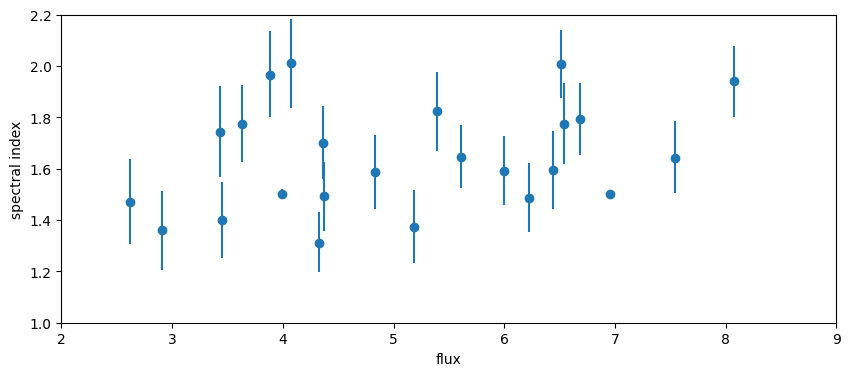

In [31]:
plt.figure(figsize=(10, 4))
plt.errorbar(data_2["x"], data_2["y"], yerr=[data_2["y"] - data_2["ymin"], data_2["ymax"] - data_2["y"]], fmt='o')

plt.xlim(2, 9)
plt.xlabel("flux")

plt.ylim(1.0, 2.2)
plt.ylabel("spectral index")

In [32]:
def find_closest(entry, database):
    dist = (entry['y'] - database['y'])**2 + (entry['ymax'] - database['ymax'])**2 + (entry['ymin'] - database['ymin'])**2 + (entry['ymax'] + entry['ymin'] - entry['y'] - database['ymin'] - database['ymax'] + database['y'])**2
    return np.argmin(dist)

index_dict = []
for index1 in data_1.index:
    entry1 = data_1.iloc[index1]
    index2 = find_closest(entry1, data_2)
    index_dict.append(int(index2))

print(index_dict)
print(data_1["y"].to_numpy().ravel())
print(data_2["y"].reindex(index_dict).to_numpy().ravel())

[8, 6, 1, 16, 3, 11, 16, 12, 21, 19, 22, 17, 13, 23, 18, 20, 4, 7, 5, 2, 15, 14, 9, 0]
[1.311 1.498 1.357 1.49  1.398 1.584 1.486 1.371 1.499 1.773 1.642 1.594
 1.823 1.938 2.006 1.79  1.774 2.008 1.965 1.742 1.591 1.644 1.699 1.469]
[1.31254545 1.50113636 1.36013636 1.48668182 1.39886364 1.58663636
 1.48668182 1.37404545 1.50140909 1.77522727 1.64322727 1.59577273
 1.825      1.94145455 2.00827273 1.79240909 1.77604545 2.01018182
 1.96709091 1.74318182 1.59236364 1.6465     1.70104545 1.47154545]


In [33]:
final_db = data_1.copy()
final_db["flux"] = data_2["x"].reindex(index_dict).to_numpy()

In [34]:
final_db

,x,y,ymin,ymax,flux
0,27.211,1.311,1.194,1.427,4.328707
1,47.838,1.498,1.479,1.520,3.993197
2,69.391,1.357,1.202,1.515,2.911565
3,79.559,1.490,1.353,1.625,6.219592
4,94.984,1.398,1.250,1.545,3.448980
5,95.676,1.584,1.438,1.732,4.835918
6,108.708,1.486,1.350,1.625,6.219592
7,120.245,1.371,1.231,1.514,5.185578
8,131.423,1.499,1.489,1.510,6.951837
9,141.909,1.773,1.615,1.929,6.539864


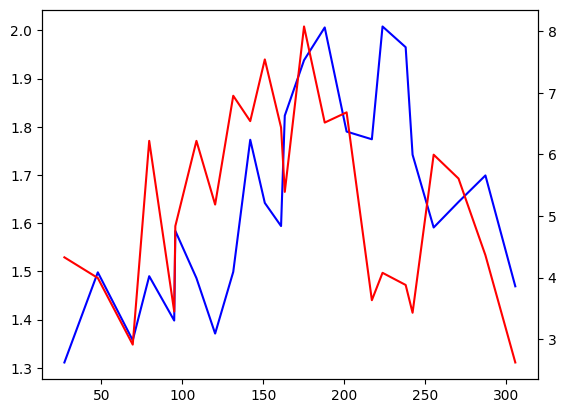

In [35]:
ax = plt.subplot(111)
ax2 = ax.twinx()
ax.plot(final_db.x, final_db.y, color='blue')
ax2.plot(final_db.x, final_db.flux, color='red')

Text(0, 0.5, 'index')

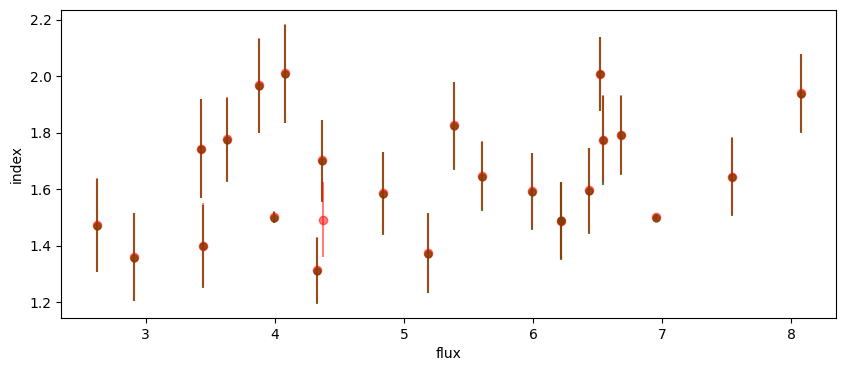

In [44]:
plt.figure(figsize=(10, 4))
plt.errorbar(final_db.flux, final_db.y, yerr=[final_db.y - final_db.ymin, final_db.ymax - final_db.y],
             color='green', elinewidth=1.5, linewidth=0, marker='o', markersize=5, alpha=.8)
plt.errorbar(data_2["x"], data_2["y"], yerr=[data_2["y"] - data_2["ymin"], data_2["ymax"] - data_2["y"]], fmt='o', alpha=.5, color='red')
plt.xlabel('flux')
plt.ylabel('index')

In [37]:
final_db = final_db.sort_values('y').reset_index()

In [38]:
final_db

,index,x,y,ymin,ymax,flux
0,0,27.211,1.311,1.194,1.427,4.328707
1,2,69.391,1.357,1.202,1.515,2.911565
2,7,120.245,1.371,1.231,1.514,5.185578
3,4,94.984,1.398,1.250,1.545,3.448980
4,23,305.496,1.469,1.306,1.635,2.621497
5,6,108.708,1.486,1.350,1.625,6.219592
6,3,79.559,1.490,1.353,1.625,6.219592
7,1,47.838,1.498,1.479,1.520,3.993197
8,8,131.423,1.499,1.489,1.510,6.951837
9,5,95.676,1.584,1.438,1.732,4.835918


In [39]:
data_2 = data_2.sort_values('y').reset_index()

In [49]:
final_db.loc[6, 'flux'] = data_2.loc[6, 'x']

Text(0, 0.5, 'index')

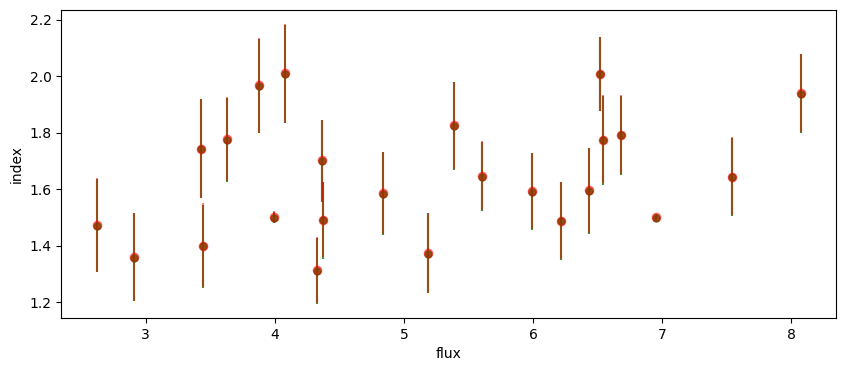

In [50]:
plt.figure(figsize=(10, 4))
plt.errorbar(final_db.flux, final_db.y, yerr=[final_db.y - final_db.ymin, final_db.ymax - final_db.y],
             color='green', elinewidth=1.5, linewidth=0, marker='o', markersize=5, alpha=.8)
plt.errorbar(data_2["x"], data_2["y"], yerr=[data_2["y"] - data_2["ymin"], data_2["ymax"] - data_2["y"]], fmt='o', alpha=.5, color='red')
plt.xlabel('flux')
plt.ylabel('index')

<ErrorbarContainer object of 3 artists>

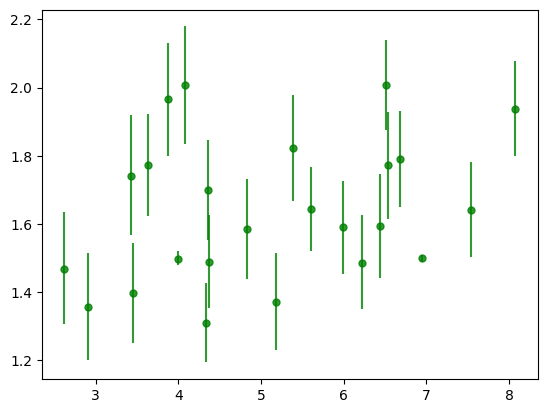

In [51]:
plt.errorbar(final_db.flux, final_db.y, yerr=[final_db.y - final_db.ymin, final_db.ymax - final_db.y],
             color='green', elinewidth=1.5, linewidth=0, marker='o', markersize=5, alpha=.8)

<ErrorbarContainer object of 3 artists>

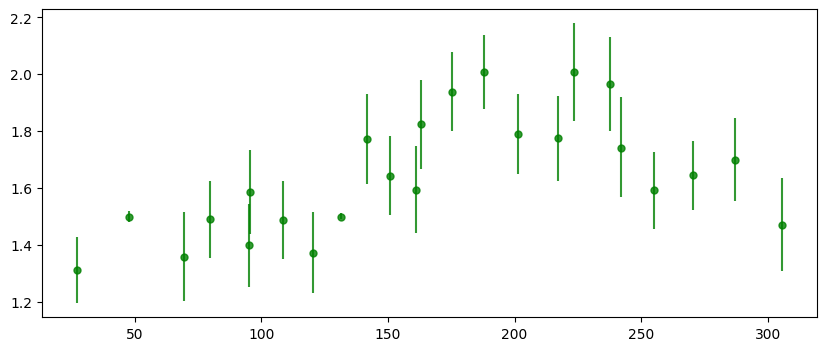

In [57]:
plt.figure(figsize=(10, 4))
plt.errorbar(final_db.x, final_db.y, yerr=[final_db.y - final_db.ymin, final_db.ymax - final_db.y],
             color='green', elinewidth=1.5, linewidth=0, marker='o', markersize=5, alpha=.8)

Text(0.5, 0, 'distance, arcsec')

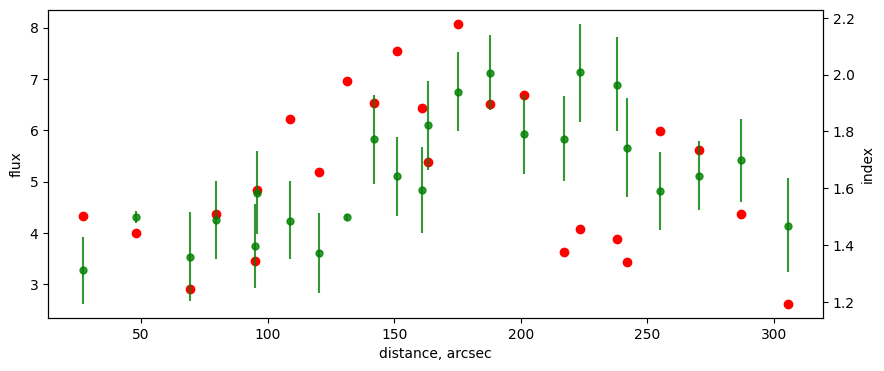

In [63]:
plt.figure(figsize=(10, 4))
ax = plt.subplot(111)
ax2 = ax.twinx()
ax.scatter(final_db.x, final_db.flux, color='red')
ax.set_ylabel('flux')

ax2.errorbar(final_db.x, final_db.y, yerr=[final_db.y - final_db.ymin, final_db.ymax - final_db.y],
             color='green', elinewidth=1.5, linewidth=0, marker='o', markersize=5, alpha=.8)
ax2.set_ylabel('index')

ax.set_xlabel('distance, arcsec')

In [53]:
final_db.to_csv("data_points_2016.csv", index=False)

### Normalized counts vs distance

In [88]:
data_nc = pd.read_csv("norm_counts-dist_2016_raw.csv", delimiter=',')

data_nc_xmin = data_nc.loc[data_nc['group']=='xmin']['distance']
data_nc_yxmin = data_nc.loc[data_nc['group']=='xmin']['value']

data_nc_xmax = data_nc.loc[data_nc['group']=='xmax']['distance']
data_nc_yxmax = data_nc.loc[data_nc['group']=='xmax']['value']

data_nc_x = data_nc.loc[data_nc['group']=='xy']['distance']
data_nc_y = data_nc.loc[data_nc['group']=='xy']['value']

data_nc_ymin = data_nc.loc[data_nc['group']=='ymin']['value']
data_nc_xymin = data_nc.loc[data_nc['group']=='ymin']['distance']

data_nc_ymax = data_nc.loc[data_nc['group']=='ymax']['value']
data_nc_xymax = data_nc.loc[data_nc['group']=='ymax']['distance']

In [108]:
data_xbnd = np.zeros(data_nc_xmin.size + 1)
data_xbnd[0] = data_nc_xmin.iloc[0]
data_xbnd[1:-1] = 0.5 * (data_nc_xmin.iloc[1:].to_numpy() + data_nc_xmax.iloc[:-1].to_numpy())
data_xbnd[-1] = data_nc_xmax.iloc[-1]

x_min = data_xbnd[:-1]
x_max = data_xbnd[1:]

In [124]:
data_xbnd

array([-132.044 , -111.602 ,  -91.713 ,  -72.928 ,  -53.8675,  -34.807 ,
        -17.0385,   -4.42  ,    6.3535,   21.171 ,   39.779 ,   59.669 ,
         80.11  ,  100.0885,  119.89  ,  140.331 ,  159.3925,  176.906 ,
        195.934 ,  214.641 ,  233.702 ,  253.591 ,  272.928 ,  294.21  ,
        314.365 ,  333.16  ,  351.381 ,  369.5135,  388.398 ])

In [114]:
x = 1/3 * (data_nc_x.to_numpy() + data_nc_xymin.to_numpy() + data_nc_xymax.to_numpy())
y = 1/3 * (data_nc_y.to_numpy() + data_nc_yxmin.to_numpy() + data_nc_yxmax.to_numpy())
y_min = data_nc_ymin.to_numpy()
y_max = data_nc_ymax.to_numpy()

In [115]:
final_nc_db = pd.DataFrame()
final_nc_db['x'] = x
final_nc_db['y'] = y
final_nc_db['xmin'] = x_min
final_nc_db['xmax'] = x_max
final_nc_db['ymin'] = y_min
final_nc_db['ymax'] = y_max

In [116]:
final_nc_db

,x,y,xmin,xmax,ymin,ymax
0,-122.099000,0.225000,-132.0440,-111.6020,0.174,0.253
1,-101.664667,0.711000,-111.6020,-91.7130,0.648,0.769
2,-82.320000,0.996000,-91.7130,-72.9280,0.885,1.091
3,-63.845667,1.064333,-72.9280,-53.8675,0.944,1.186
4,-44.626000,1.549000,-53.8675,-34.8070,1.402,1.692
5,-24.243000,1.282667,-34.8070,-17.0385,1.202,1.391
6,-8.840000,1.792000,-17.0385,-4.4200,1.613,1.960
7,0.000000,4.522000,-4.4200,6.3535,4.522,4.522
8,12.096000,2.505333,6.3535,21.1710,2.350,2.635
9,29.826667,1.763667,21.1710,39.7790,1.681,1.834


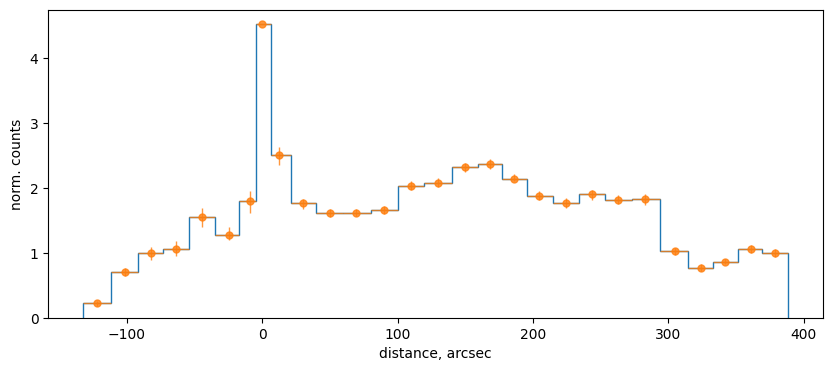

In [130]:
plt.figure(figsize=(10, 4))
plt.stairs(final_nc_db.y, data_xbnd)
plt.errorbar(final_nc_db.x, final_nc_db.y,
             xerr = [final_nc_db.x - final_nc_db.xmin, final_nc_db.xmax - final_nc_db.x],
             yerr = [final_nc_db.y - final_nc_db.ymin, final_nc_db.ymax - final_nc_db.y],
             elinewidth=1, linestyle='None', marker='o', markersize=5, alpha=.8)
plt.xlabel('distance, arcsec')
plt.ylabel('norm. counts')
plt.show()

In [133]:
final_nc_db.to_csv("norm_counts-dist_2016.csv", index=False, float_format='%.3f')